<a href="https://colab.research.google.com/github/davidestebansalgadoforero1508-oss/analisis-hurtos-bogota/blob/main/Proyecto_Ciencia_Datos_Seguridad_Bogota.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd

# Cargar el dataset (reemplaza el texto entre comillas con la ruta de tu archivo)
ruta_archivo = '/content/Reporte_Hurto_por_Modalidades_Policía_Nacional_20260831.csv'
df = pd.read_csv(ruta_archivo)

# Ver las primeras 3 filas para revisar cómo se ven los datos
print("--- Vista previa de los datos ---")
display(df.head(3))

# Ver el resumen de columnas y tipos de datos
print("\n--- Información general del Dataset ---")
df.info()

/tmp/ipykernel_1868/1423512955.py:5: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta_archivo)


--- Vista previa de los datos ---


,DEPARTAMENTO,MUNICIPIO,CODIGO DANE,ARMAS MEDIOS,FECHA HECHO,GENERO,GRUPO ETARIO,TIPO DE HURTO,CANTIDAD
0,CESAR,Chiriguaná,20178000,NO REPORTADO,24/03/2026,NaN,ADULTOS,ARTÍCULO 239. HURTO ENTIDADES COMERCIALES,1
1,ATLÁNTICO,Soledad,8758000,NO REPORTADO,16/03/2026,NaN,ADULTOS,ARTÍCULO 239. HURTO ENTIDADES COMERCIALES,1
2,BOGOTA,Bogotá D.C. (CT),11001000,NO REPORTADO,24/02/2026,NaN,ADULTOS,ARTÍCULO 239. HURTO ENTIDADES COMERCIALES,1



--- Información general del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 633804 entries, 0 to 633803
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   DEPARTAMENTO   633804 non-null  object
 1   MUNICIPIO      633803 non-null  object
 2   CODIGO DANE    633804 non-null  int64 
 3   ARMAS MEDIOS   633804 non-null  object
 4   FECHA HECHO    633804 non-null  object
 5   GENERO         61846 non-null   object
 6   GRUPO ETARIO   577179 non-null  object
 7   TIPO DE HURTO  633804 non-null  object
 8   CANTIDAD       633804 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 43.5+ MB


In [8]:
# --- DIAGNÓSTICO DE CALIDAD DE DATOS ---
print("--- 1. Cantidad de filas duplicadas ---")
print(f"Duplicados encontrados: {df.duplicated().sum()}")

print("\n--- 2. Porcentaje de valores nulos por columna ---")
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100
df_nulos = pd.DataFrame({'Valores Nulos': nulos, 'Porcentaje (%)': porcentaje_nulos})
display(df_nulos[df_nulos['Valores Nulos'] > 0])

--- 1. Cantidad de filas duplicadas ---
Duplicados encontrados: 247603

--- 2. Porcentaje de valores nulos por columna ---


,Valores Nulos,Porcentaje (%)
MUNICIPIO,1,0.000158
GENERO,571958,90.242094
GRUPO ETARIO,56625,8.934150


In [9]:
# --- FASE DE LIMPIEZA DE DATOS ---

# 1. Eliminar filas completamente duplicadas
print(f"Filas antes de eliminar duplicados: {len(df)}")
df = df.drop_duplicates()
print(f"Filas después de eliminar duplicados: {len(df)}")

# 2. Rellenar o tratar los valores nulos críticos
# Para 'GENERO', como el 90% está vacío, lo mejor es imputarlo con una etiqueta clara como 'NO REPORTADO' o 'DESCONOCIDO' para no perder las filas.
df['GENERO'] = df['GENERO'].fillna('NO REPORTADO')

# Para 'GRUPO ETARIO', también podemos rellenarlo con 'NO REPORTADO'
df['GRUPO ETARIO'] = df['GRUPO ETARIO'].fillna('NO REPORTADO')

# Para el único nulo de 'MUNICIPIO', podemos eliminar esa fila puntual o rellenarla
df = df.dropna(subset=['MUNICIPIO'])

# 3. Verificamos que ya no queden nulos
print("\n--- Verificación final de nulos después de la limpieza ---")
print(df.isnull().sum())

Filas antes de eliminar duplicados: 633804
Filas después de eliminar duplicados: 386201

--- Verificación final de nulos después de la limpieza ---
DEPARTAMENTO     0
MUNICIPIO        0
CODIGO DANE      0
ARMAS MEDIOS     0
FECHA HECHO      0
GENERO           0
GRUPO ETARIO     0
TIPO DE HURTO    0
CANTIDAD         0
dtype: int64


In [10]:
# --- FILTRADO ESPACIAL Y TEMPORAL PARA BOGOTÁ (2023-2025) ---

# 1. Asegurar que la fecha sea de tipo datetime
df['FECHA HECHO'] = pd.to_datetime(df['FECHA HECHO'], errors='coerce')

# 2. Filtrar por la ciudad de Bogotá D.C. (revisando variaciones comunes en el nombre)
df_bogota = df[df['MUNICIPIO'].str.upper().str.contains('BOGOTÁ', na=False)].copy()

# 3. Extraer el año para filtrar el periodo de interés (2023 a 2025)
df_bogota['AÑO'] = df_bogota['FECHA HECHO'].dt.year
df_bogota_2023_2025 = df_bogota[df_bogota['AÑO'].between(2023, 2025)].copy()

# 4. Ver el resultado del filtro
print(f"Total de registros limpios para Bogotá entre 2023 y 2025: {len(df_bogota_2023_2025)}")
print("\nDistribución de hurtos por año en Bogotá:")
print(df_bogota_2023_2025['AÑO'].value_counts().sort_index())

/tmp/ipykernel_1868/379220939.py:4: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['FECHA HECHO'] = pd.to_datetime(df['FECHA HECHO'], errors='coerce')


Total de registros limpios para Bogotá entre 2023 y 2025: 8873

Distribución de hurtos por año en Bogotá:
AÑO
2023    1704
2024    3814
2025    3355
Name: count, dtype: int64


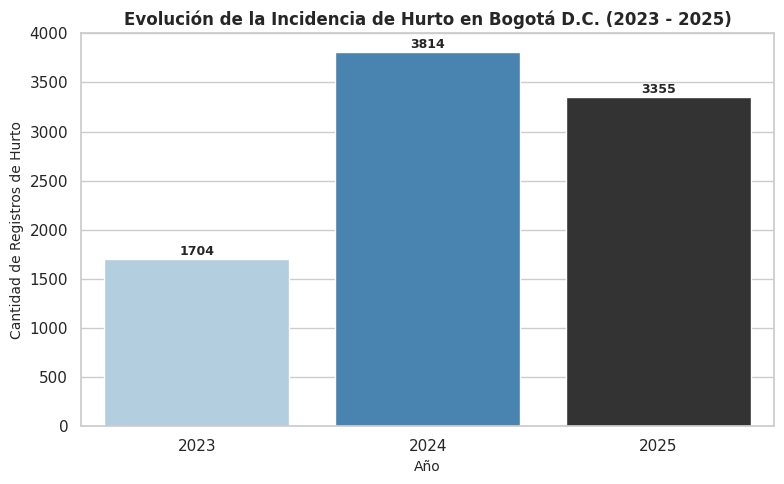

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética limpia
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Gráfico de barras por año
ax = sns.countplot(data=df_bogota_2023_2025, x='AÑO', palette='Blues_d', hue='AÑO', legend=False)

plt.title('Evolución de la Incidencia de Hurto en Bogotá D.C. (2023 - 2025)', fontsize=12, fontweight='bold')
plt.xlabel('Año', fontsize=10)
plt.ylabel('Cantidad de Registros de Hurto', fontsize=10)

# Añadir las etiquetas de los valores exactos sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

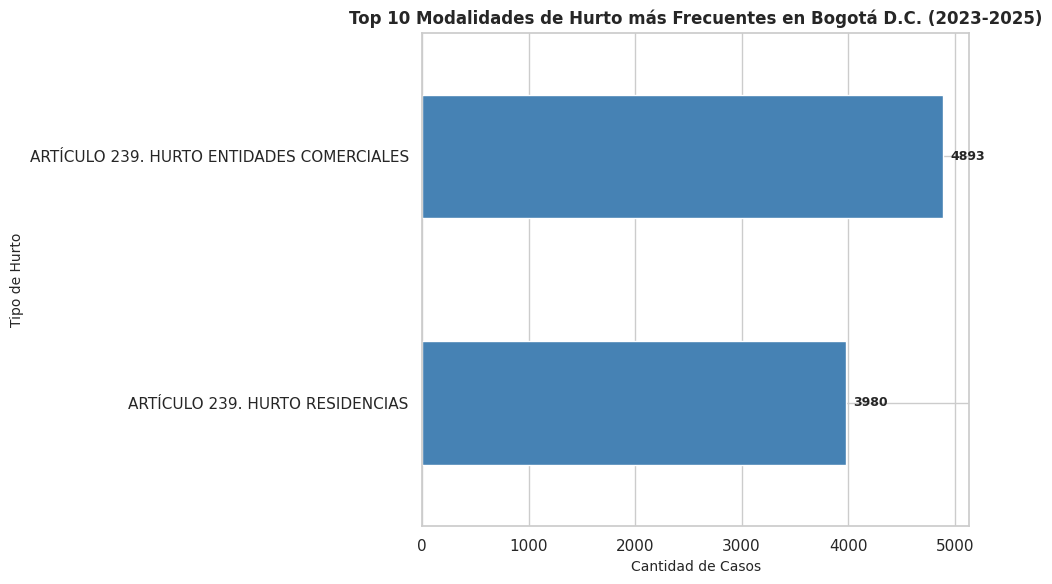

In [12]:
# --- ANÁLISIS DE MODALIDADES DE HURTO MÁS FRECUENTES EN BOGOTÁ ---
plt.figure(figsize=(10, 6))

# Agrupar y tomar el Top 10 de tipos de hurto
top_hurtos = df_bogota_2023_2025['TIPO DE HURTO'].value_counts().head(10).sort_values(ascending=True)

ax = top_hurtos.plot(kind='barh', color='steelblue')

plt.title('Top 10 Modalidades de Hurto más Frecuentes en Bogotá D.C. (2023-2025)', fontsize=12, fontweight='bold')
plt.xlabel('Cantidad de Casos', fontsize=10)
plt.ylabel('Tipo de Hurto', fontsize=10)

# Añadir las etiquetas numéricas al final de cada barra horizontal
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
# --- TABLA DE FRECUENCIA DE TIPOS DE HURTO EN BOGOTÁ (2023-2025) ---
print(df_bogota_2023_2025['TIPO DE HURTO'].value_counts())

TIPO DE HURTO
ARTÍCULO 239. HURTO ENTIDADES COMERCIALES    4893
ARTÍCULO 239. HURTO RESIDENCIAS              3980
Name: count, dtype: int64


In [14]:
# --- REVISIÓN DE COLUMNAS DISPONIBLES PARA ANÁLISIS ESPACIAL ---
print(df_bogota_2023_2025.columns.tolist())

['DEPARTAMENTO', 'MUNICIPIO', 'CODIGO DANE', 'ARMAS MEDIOS', 'FECHA HECHO', 'GENERO', 'GRUPO ETARIO', 'TIPO DE HURTO', 'CANTIDAD', 'AÑO']


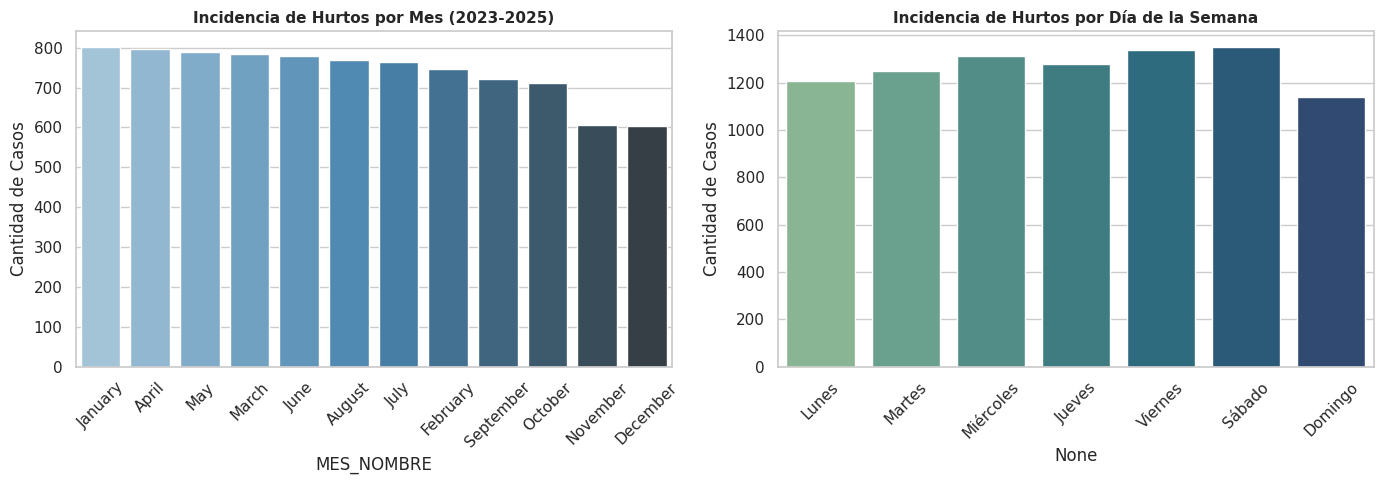

--- Resumen Numérico Pregunta 3 ---
Top 3 Meses:
 MES_NOMBRE
January    801
April      796
May        788
Name: count, dtype: int64

Top 3 Días:
 Sábado       1349
Viernes      1337
Miércoles    1313
Name: count, dtype: int64


In [17]:
# --- PREGUNTA 3 (CORREGIDA): Patrones Temporales (Días y Meses) ---
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gráfico por Mes
df_bogota_2023_2025['MES_NOMBRE'] = df_bogota_2023_2025['FECHA HECHO'].dt.month_name()
conteo_meses = df_bogota_2023_2025['MES_NOMBRE'].value_counts()
sns.barplot(x=conteo_meses.index, y=conteo_meses.values, ax=axes[0], palette='Blues_d', hue=conteo_meses.index, legend=False)
axes[0].set_title('Incidencia de Hurtos por Mes (2023-2025)', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Cantidad de Casos')

# 2. Gráfico por Día de la Semana (Corregido con value_counts)
df_bogota_2023_2025['DIA_SEMANA'] = df_bogota_2023_2025['FECHA HECHO'].dt.day_name()
dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_español = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

conteo_dias = df_bogota_2023_2025['DIA_SEMANA'].value_counts().reindex(dias_ordenados)
conteo_dias.index = dias_español # Cambiar etiquetas a español para mayor claridad

sns.barplot(x=conteo_dias.index, y=conteo_dias.values, ax=axes[1], palette='crest', hue=conteo_dias.index, legend=False)
axes[1].set_title('Incidencia de Hurtos por Día de la Semana', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Cantidad de Casos')

plt.tight_layout()
plt.show()

print("--- Resumen Numérico Pregunta 3 ---")
print("Top 3 Meses:\n", conteo_meses.head(3))
print("\nTop 3 Días:\n", conteo_dias.sort_values(ascending=False).head(3))

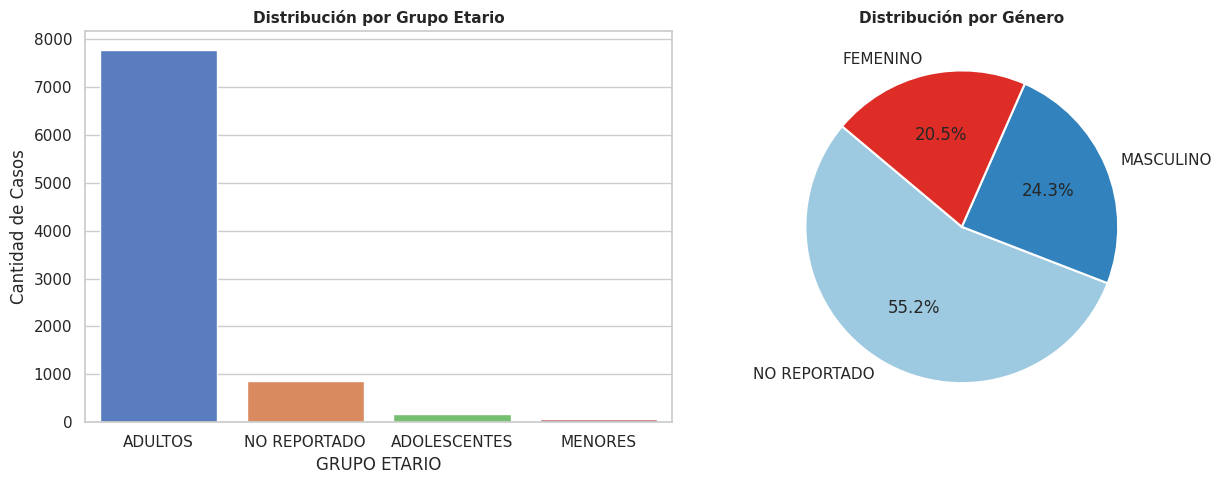

--- Resumen Numérico Pregunta 4 ---
Grupo Etario:
 GRUPO ETARIO
ADULTOS         7775
NO REPORTADO     870
ADOLESCENTES     170
MENORES           58
Name: count, dtype: int64

Género:
 GENERO
NO REPORTADO    4901
MASCULINO       2154
FEMENINO        1818
Name: count, dtype: int64


In [18]:
# --- PREGUNTA 4: Perfil de las Víctimas (Género y Grupo Etario) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Grupo Etario
conteo_etario = df_bogota_2023_2025['GRUPO ETARIO'].value_counts()
sns.barplot(x=conteo_etario.index, y=conteo_etario.values, ax=axes[0], palette='muted', hue=conteo_etario.index, legend=False)
axes[0].set_title('Distribución por Grupo Etario', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Cantidad de Casos')

# 2. Género
conteo_genero = df_bogota_2023_2025['GENERO'].value_counts()
axes[1].pie(conteo_genero.values, labels=conteo_genero.index, autopct='%1.1f%%',
            colors=['#9ecae1', '#3182bd', '#de2d26'], startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Distribución por Género', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("--- Resumen Numérico Pregunta 4 ---")
print("Grupo Etario:\n", conteo_etario)
print("\nGénero:\n", conteo_genero)

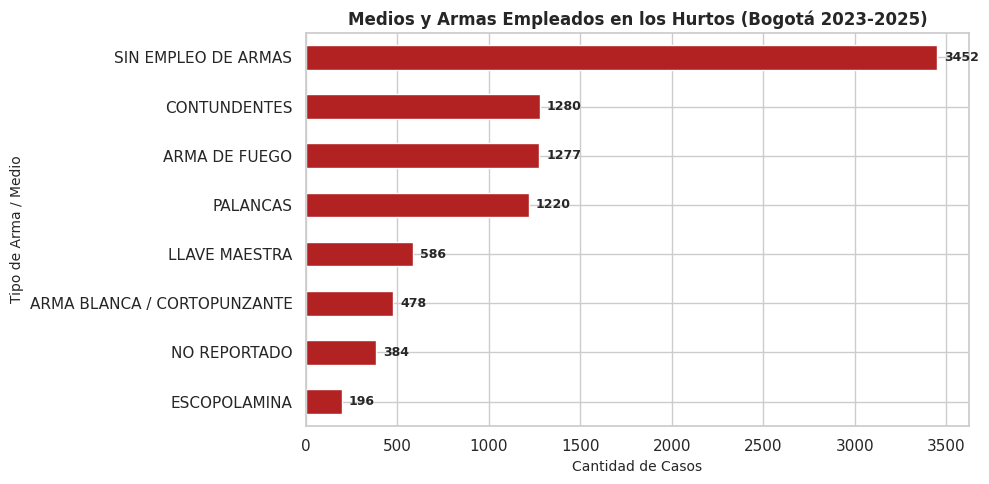

--- Porcentajes Exactos (Pregunta 5) ---
ARMAS MEDIOS
SIN EMPLEO DE ARMAS            38.90
CONTUNDENTES                   14.43
ARMA DE FUEGO                  14.39
PALANCAS                       13.75
LLAVE MAESTRA                   6.60
ARMA BLANCA / CORTOPUNZANTE     5.39
NO REPORTADO                    4.33
ESCOPOLAMINA                    2.21
Name: proportion, dtype: float64


In [21]:
# --- PREGUNTA 5: Análisis de Armas o Medios Utilizados ---
plt.figure(figsize=(10, 5))

conteo_armas = df_bogota_2023_2025['ARMAS MEDIOS'].value_counts().sort_values(ascending=True)
ax = conteo_armas.plot(kind='barh', color='firebrick')

plt.title('Medios y Armas Empleados en los Hurtos (Bogotá 2023-2025)', fontsize=12, fontweight='bold')
plt.xlabel('Cantidad de Casos', fontsize=10)
plt.ylabel('Tipo de Arma / Medio', fontsize=10)

# Etiquetas numéricas al final de las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("--- Porcentajes Exactos (Pregunta 5) ---")
print((df_bogota_2023_2025['ARMAS MEDIOS'].value_counts(normalize=True) * 100).round(2))

In [20]:
# --- EXPORTAR A EXCEL EL DATASET LIMPIO DE BOGOTÁ (2023-2025) ---
nombre_archivo_excel = "Hurto_Bogota_2023_2025_Limpio.xlsx"

# Guardar el DataFrame filtrado en un archivo Excel
df_bogota_2023_2025.to_excel(nombre_archivo_excel, index=False, sheet_name='Bogota_2023_2025')

print(f"¡Archivo Excel generado con éxito!")
print(f"Nombre del archivo: {nombre_archivo_excel}")
print(f"Total de registros guardados: {len(df_bogota_2023_2025)}")

¡Archivo Excel generado con éxito!
Nombre del archivo: Hurto_Bogota_2023_2025_Limpio.xlsx
Total de registros guardados: 8873
